In [1]:
%load_ext autoreload

In [2]:
%autoreload 1

In [3]:
import os, re, sys
import numpy as np
from rich import print
from rich.pretty import pprint
from rich.progress import track
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.backends.backend_pdf import PdfPages
import hist
from hist import Hist
import mplhep as hep
import uproot
from rich.progress import Progress

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import cms_styles

%aimport plot_utils

In [4]:
mpl.rcParams.update({"figure.max_open_warning": 0})
hep.style.use("CMS")
np.set_printoptions(suppress=True)

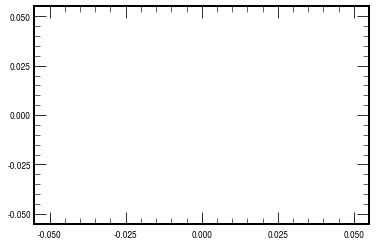

In [5]:
plt.plot()
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"
plt.style.use(cms_styles.CMS_petroff_10)

In [6]:
def merge_runs(plots, run):
    names = [
        "Higgs",
        "TTV",
        "ST_NLO",
        "WJets",
        "VV+VVV",
        "TT_powheg",
        "DY",
        "QCD_Pt_MuEnrichedPt5",
        "total_bkg",
    ]
    # Add signal processes
    signal_processes = list(
        set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13TeV", p))
    )
    # Remove 2016APV for now
    # years = ["2016APV", "2016", "2017", "2018"]
    years = ["2016", "2017", "2018"]
    if run == "Run3":
        names.remove("TTV")
        names.remove("ST_NLO")
        years = ["2022", "2022EE", "2023", "2023BPix"]
        # Add signal processes
        signal_processes = list(
            set(p[:-5] for p in plots.keys() if re.search("GluGluToSUEP.*13p6TeV", p))
        )
    names.append("Data")
    names.extend(signal_processes)
    run_plots = {}
    for name in names:
        run_plots[f"{name}_{run}"] = {}
        for year in years:
            if f"{name}_{year}" not in plots.keys():
                continue
            for plot in plots[f"{name}_{year}"]:
                if plot not in run_plots[f"{name}_{run}"].keys():
                    run_plots[f"{name}_{run}"][plot] = plots[f"{name}_{year}"][
                        plot
                    ].copy()
                else:
                    run_plots[f"{name}_{run}"][plot] += plots[f"{name}_{year}"][plot]
    return run_plots

In [7]:
plots = {}
years_to_load = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
]
for year in track(years_to_load, description="Loading plots"):
    plots = plots | plot_utils.loader(
        tag=f"checkSFs_Jun2025_{year}",
        era=year,
        load_data=True,
    )
run2_plots = merge_runs(plots, "Run2")
plots = plots | run2_plots
run3_plots = merge_runs(plots, "Run3")
plots = plots | run3_plots

Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00
Loading plots ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00

In [35]:
plots["total_bkg_2018"]["CR_cb_dxy_vs_dxyErr"].axes

(Regular(25, 0.01, 0.2, transform=log, name='muon_dxy'),
 Regular(30, 0.0005, 0.05, transform=log, name='muon_dxyErr'),
 Regular(4, 1, 5, name='nMuon'))

In [20]:
plots["Data_2018"]["CR_prompt_ip3d_vs_sip3d"].axes[2].edges[:-1]

array([2., 3., 4., 5.])

2016APV

total_bkg

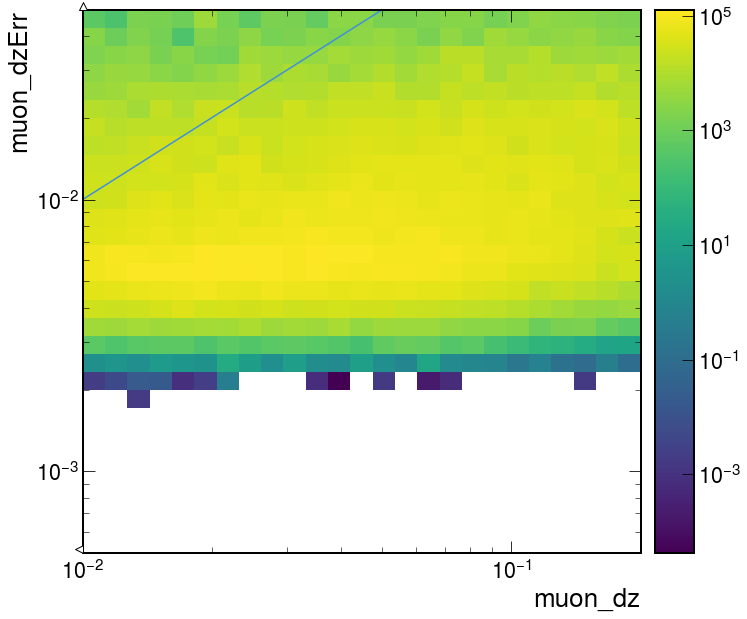

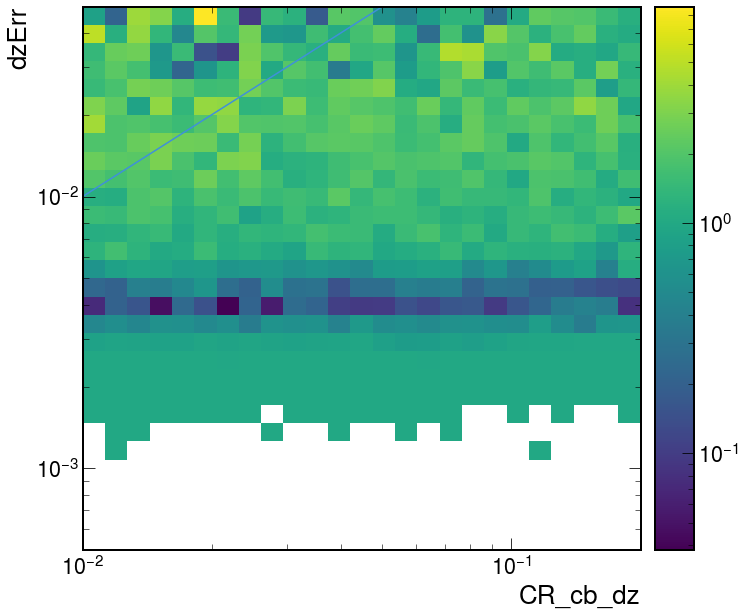

2016

total_bkg

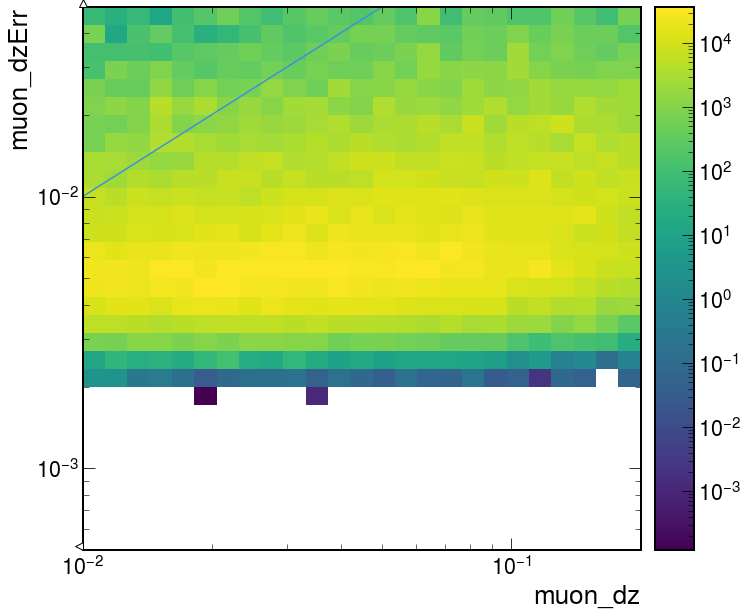

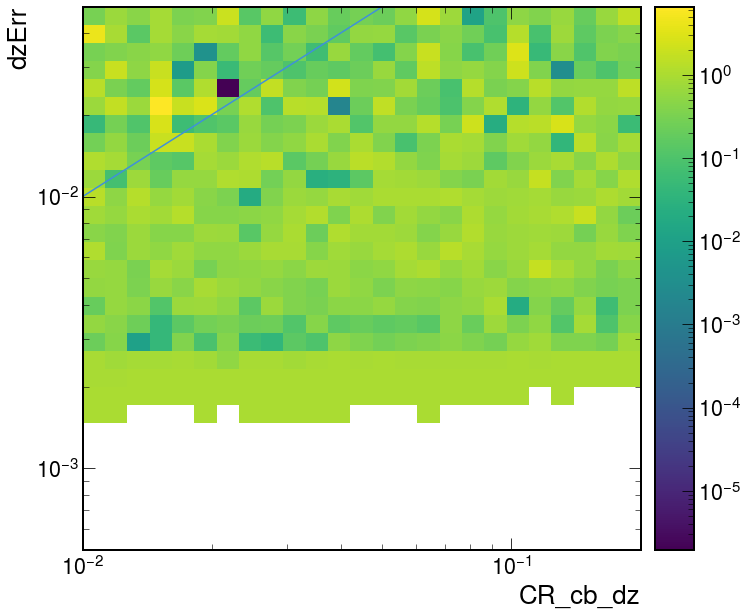

2017

total_bkg

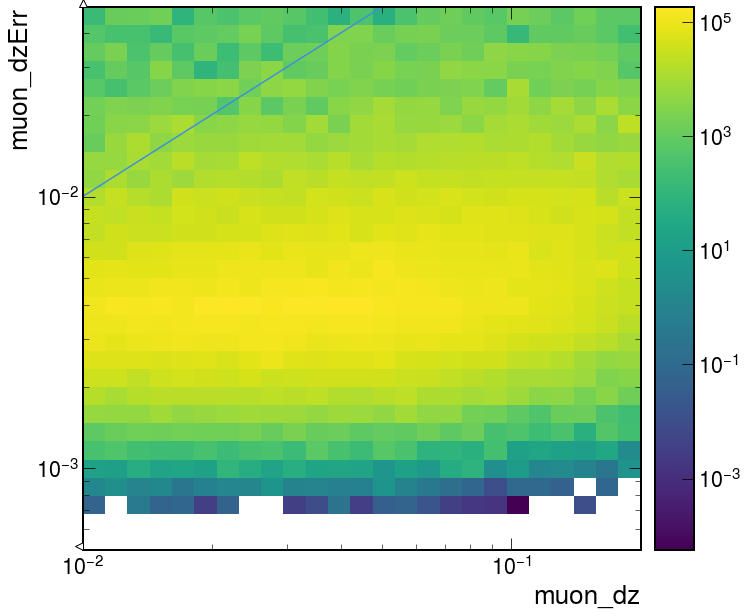

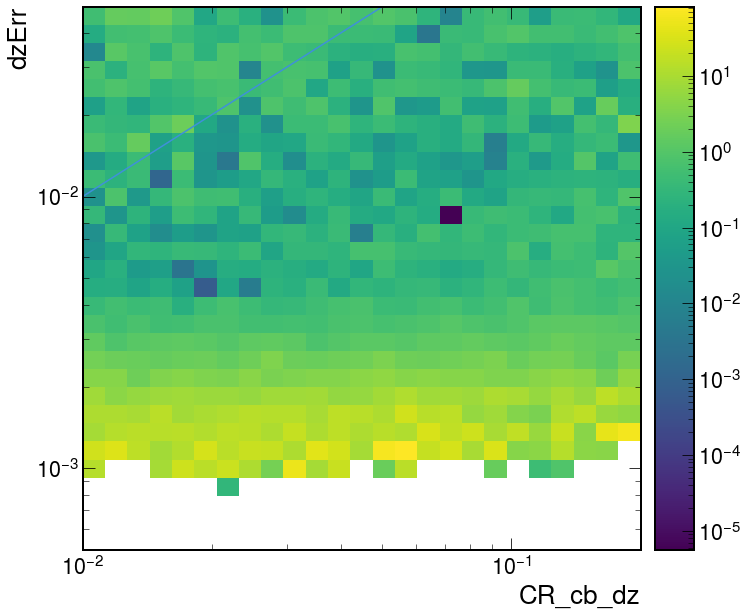

2018

total_bkg

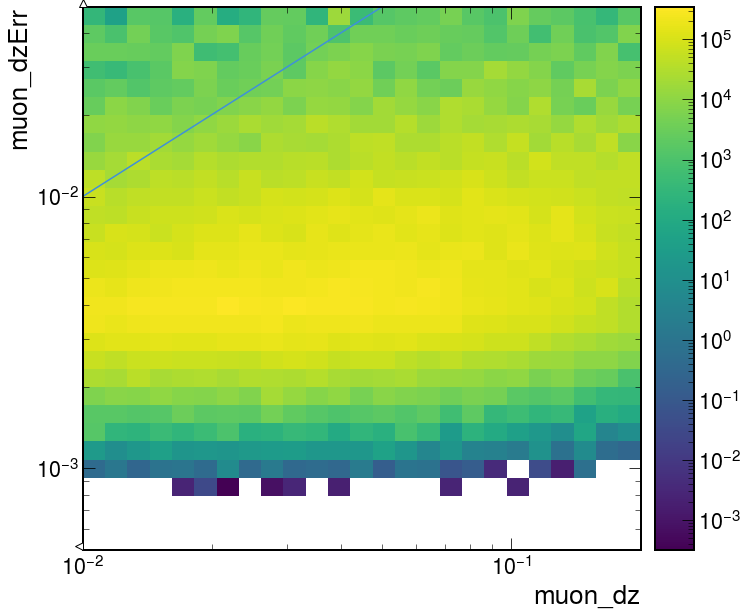

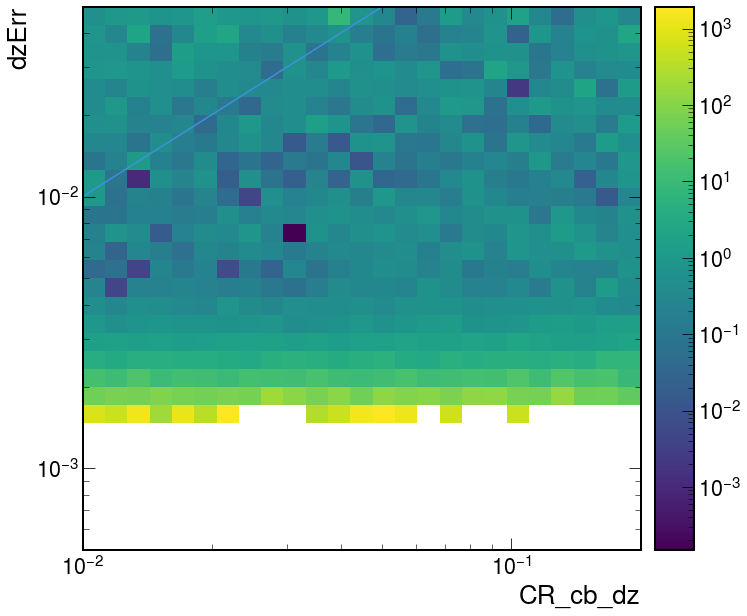

2022

total_bkg

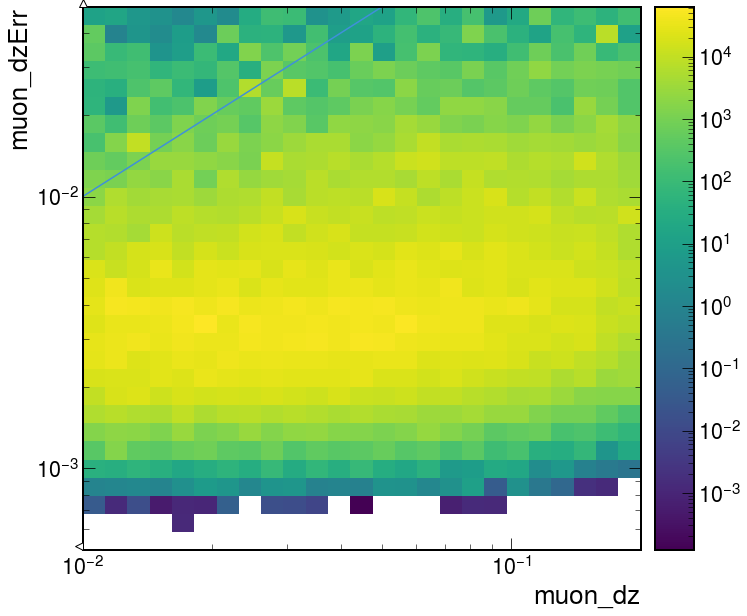

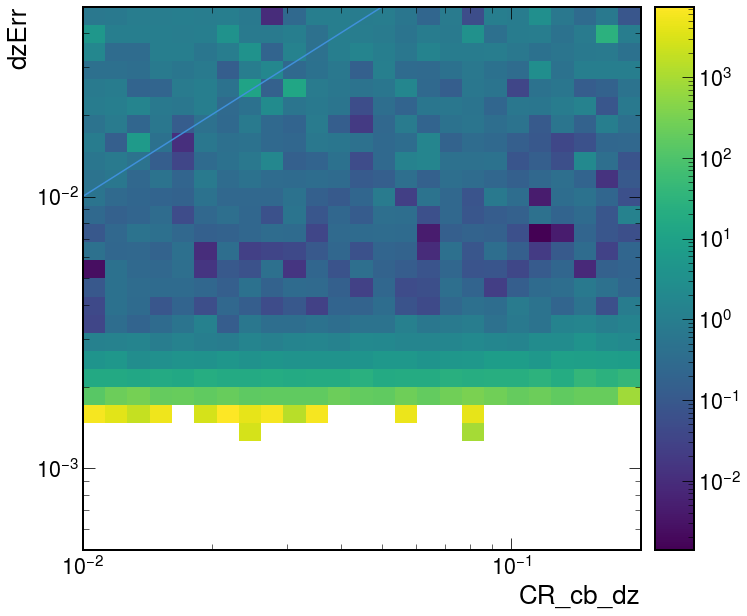

2022EE

total_bkg

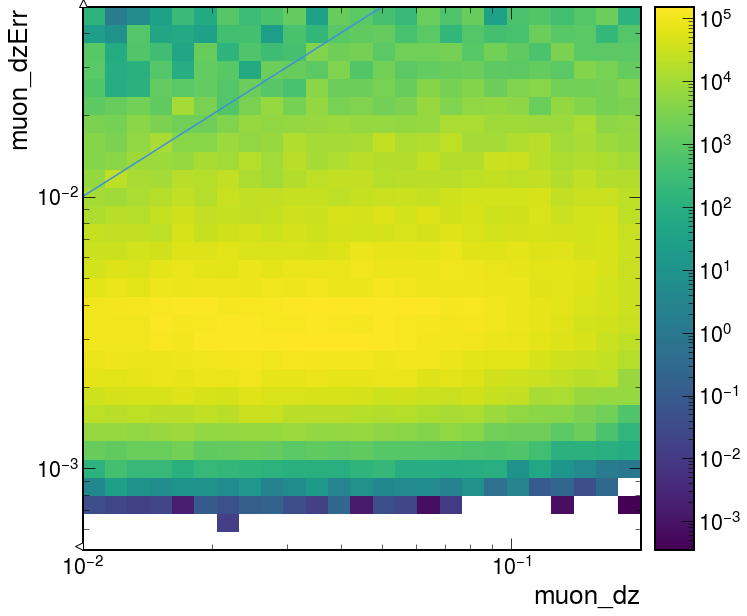

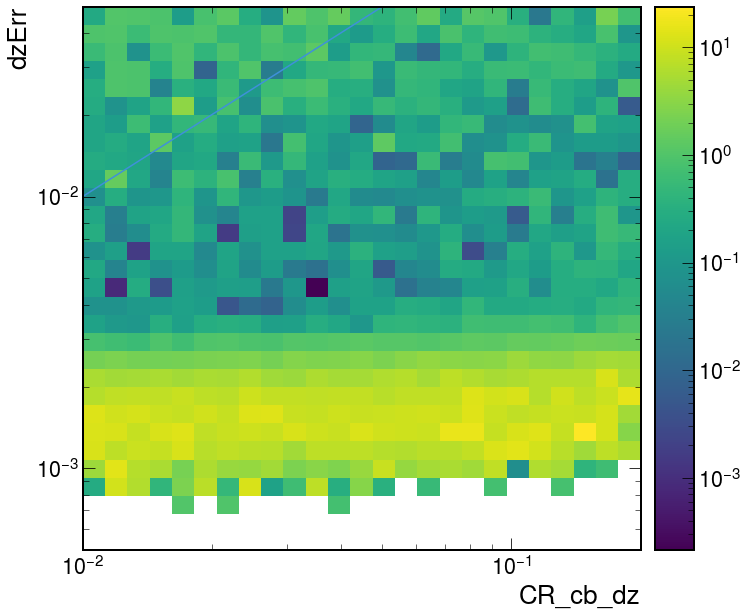

2023

total_bkg

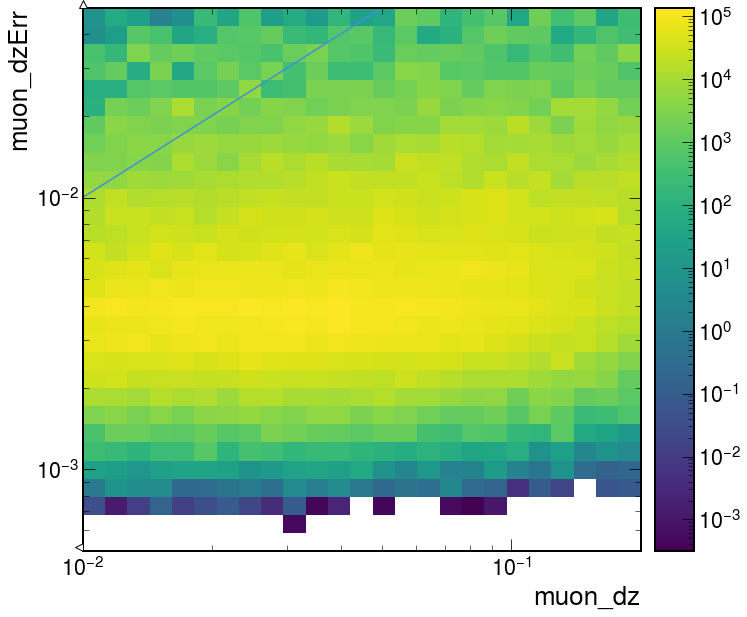

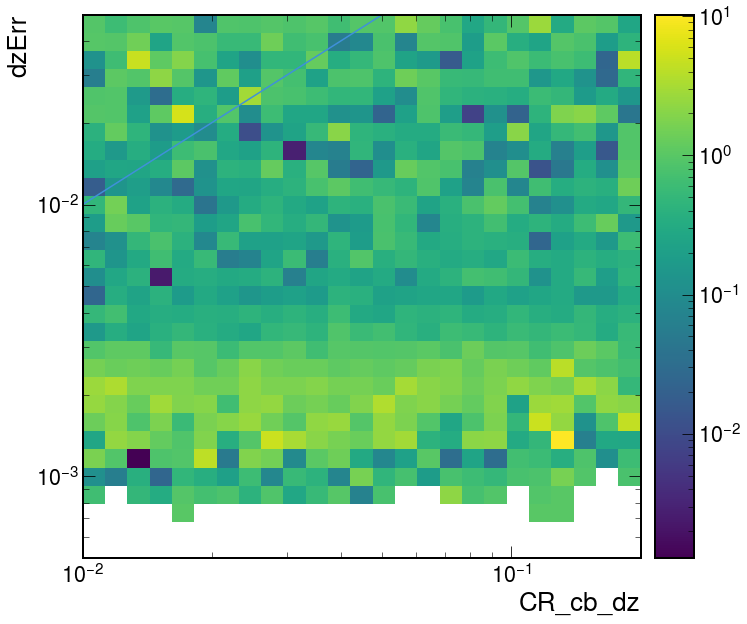

2023BPix

total_bkg

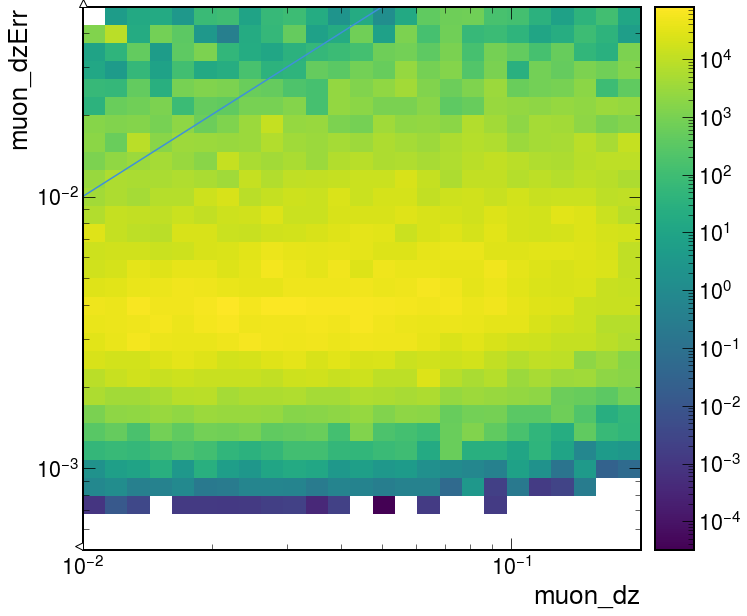

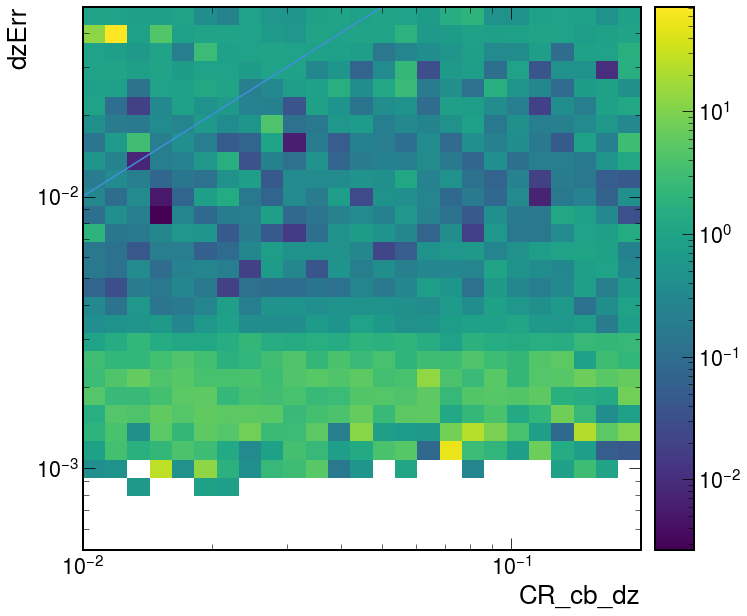

In [27]:
region = "cb"
for year in ["2016APV", "2016", "2017", "2018", "2022", "2022EE", "2023", "2023BPix"]:
    print(year)
    for variable in [
        f"CR_{region}_dz_vs_dzErr"
    ]:  # [f"CR_{region}_dxy_vs_dxyErr", f"CR_{region}_dz_vs_dzErr"]:
        # for nMuon in plots[f"Data_{year}"][variable].axes[2].edges[:-1]:
        # print("nMuon = ", nMuon)
        h_data = plots[f"Data_{year}"][variable][0.005j::1j, ::1j, ::sum]
        h_tot_bkg = plots[f"total_bkg_{year}"][variable][0.005j::1j, ::1j, ::sum]
        # print("Data")
        # plots["Data_2018"][variable].plot2d(norm=mpl.colors.LogNorm())
        # plt.plot([0,1], [0,1])
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.show()

        print("total_bkg")
        h_tot_bkg.plot2d(norm=mpl.colors.LogNorm())
        plt.plot([0, 1], [0, 1])
        plt.xscale("log")
        plt.yscale("log")
        plt.show()

        # print("ratio")
        # hep.hist2dplot(
        #     np.divide(
        #         plots["total_bkg_2018"][variable].values(),
        #         plots["Data_2018"][variable].values(),
        #         out = np.zeros((25, 25)),
        #         where = plots["Data_2018"][variable].values() > 0,
        #     ),
        #     xbins=plots["total_bkg_2018"][variable].axes[0].edges,
        #     ybins=plots["total_bkg_2018"][variable].axes[1].edges,
        #     norm=mpl.colors.LogNorm()
        # )
        # plt.plot([0,1], [0,1])
        # plt.xlabel(variable.split("_vs_")[0])
        # plt.ylabel(variable.split("_vs_")[1])
        # plt.xscale('log')
        # plt.yscale('log')
        # plt.show()
        # print("rel. diff.")

        hep.hist2dplot(
            abs(
                np.divide(
                    h_data.values() - h_tot_bkg.values(),
                    h_data.values(),
                    out=np.zeros(
                        (
                            len(h_tot_bkg.axes[0].edges) - 1,
                            len(h_tot_bkg.axes[1].edges) - 1,
                        )
                    ),
                    where=h_data.values() != 0,
                )
            ),
            xbins=h_tot_bkg.axes[0].edges,
            ybins=h_tot_bkg.axes[1].edges,
            norm=mpl.colors.LogNorm(),
        )
        plt.plot([0, 1], [0, 1])
        plt.xlabel(variable.split("_vs_")[0])
        plt.ylabel(variable.split("_vs_")[1])
        plt.xscale("log")
        plt.yscale("log")
        plt.show()

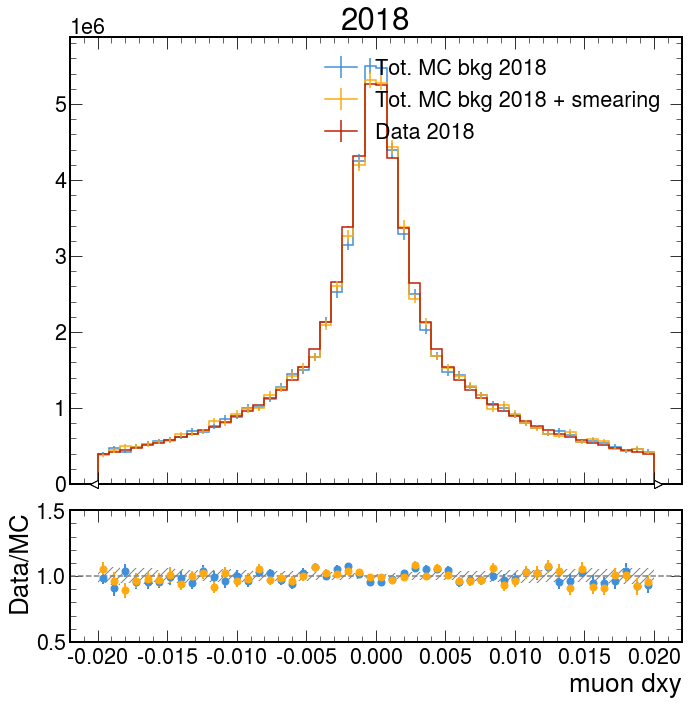

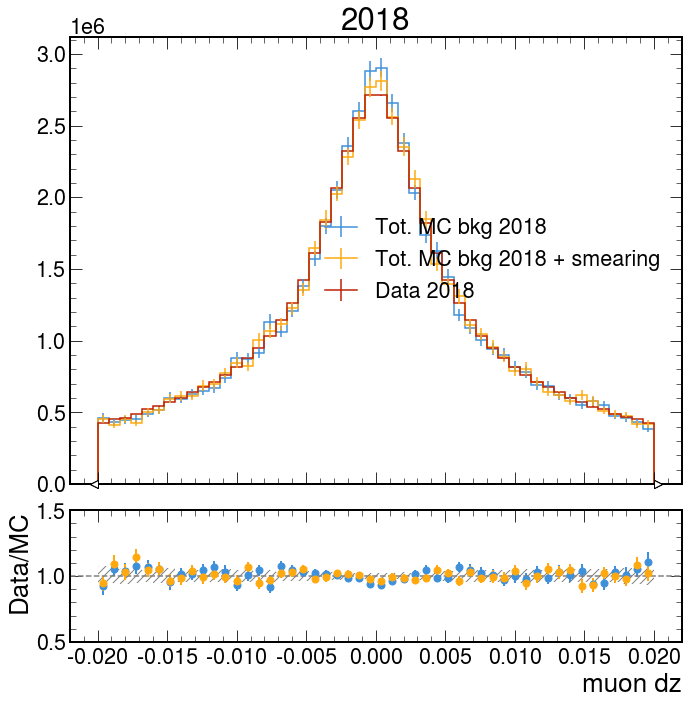

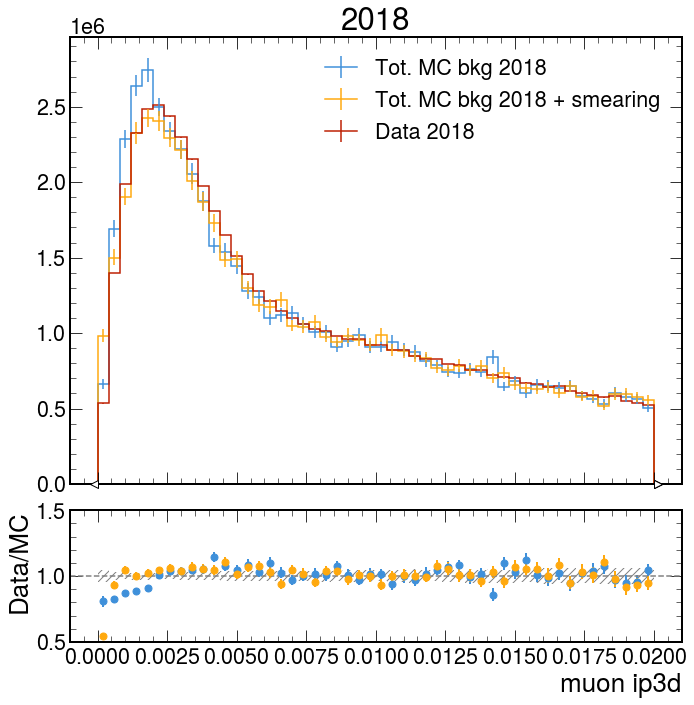

In [8]:
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]

for era in ["2018"]:
    for variable in ["dxy", "dz", "ip3d"]:
        hist_data = plots[f"Data_{era}"][f"muon_{variable}"][::2j]
        hist_bkg_total = plots[f"total_bkg_{era}"][f"muon_{variable}"][::2j]
        hist_bkg_total_sm = plots[f"total_bkg_{era}"][f"muon_{variable}_smeared"][::2j]

        # Normalize
        normalization = hist_data.sum().value / hist_bkg_total.sum().value
        hist_bkg_total = hist_bkg_total * normalization
        hist_bkg_total_sm = hist_bkg_total_sm * normalization

        fig = plt.figure(figsize=(10, 10))
        plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
        ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
        ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

        hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
        hist_bkg_total_sm.plot(label=f"Tot. MC bkg {era} + smearing", ax=ax1)
        hist_data.plot(label=f"Data {era}", ax=ax1)

        x_hatch = np.vstack(
            (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
        ).reshape((-1,), order="F")

        ratio = np.divide(
            hist_data.values(),
            hist_bkg_total.values(),
            out=np.ones_like(hist_data.values()),
            where=hist_bkg_total.values() != 0,
        )
        ratio_err = np.where(
            hist_bkg_total.values() > 0,
            np.sqrt(
                (hist_bkg_total.values() ** -2) * (hist_data.variances())
                + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                * (hist_bkg_total.variances())
            ),
            0,
        )
        ax2.errorbar(
            hist_data.axes.centers[0],
            ratio,
            yerr=ratio_err,
            color="C0",
            fmt="o",
            linestyle="none",
            markersize=7,
            lw=2,
        )

        ratio_sm = np.divide(
            hist_data.values(),
            hist_bkg_total_sm.values(),
            out=np.ones_like(hist_data.values()),
            where=hist_bkg_total_sm.values() != 0,
        )
        ratio_err_sm = np.where(
            hist_bkg_total_sm.values() > 0,
            np.sqrt(
                (hist_bkg_total_sm.values() ** -2) * (hist_data.variances())
                + (hist_data.values() ** 2 * hist_bkg_total_sm.values() ** -4)
                * (hist_bkg_total_sm.variances())
            ),
            0,
        )
        ax2.errorbar(
            hist_data.axes.centers[0],
            ratio_sm,
            yerr=ratio_err_sm,
            color="C1",
            fmt="o",
            linestyle="none",
            markersize=7,
            lw=2,
        )

        # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
        mc_rel_unc = np.divide(
            np.sqrt(hist_bkg_total.variances()),
            hist_bkg_total.values(),
            out=np.zeros_like(hist_bkg_total.values()),
            where=hist_bkg_total.values() != 0,
        )
        y_hatch2 = np.vstack(
            (
                np.ones_like(hist_bkg_total.values()),
                np.ones_like(hist_bkg_total.values()),
            )
        ).reshape((-1,), order="F")
        y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
        ax2.fill_between(
            x=x_hatch,
            y1=y_hatch2 - y_hatch2_unc,
            y2=y_hatch2 + y_hatch2_unc,
            step="pre",
            facecolor="none",
            edgecolor=(0, 0, 0, 0.5),
            linewidth=0,
            hatch="///",
        )
        ax2.axhline(1, ls="--", color="gray")

        if variable == "iso":
            plt.xscale("log")
        # ax1.set_yscale("log")
        plt.sca(ax2)
        plt.xlabel(f"muon {variable}")
        plt.ylim(0.5, 1.5)
        plt.ylabel("Data/MC")
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_xlabel("", visible=False)
        ax1.set_title(f"{era}")
        ax1.legend()
        plt.show()

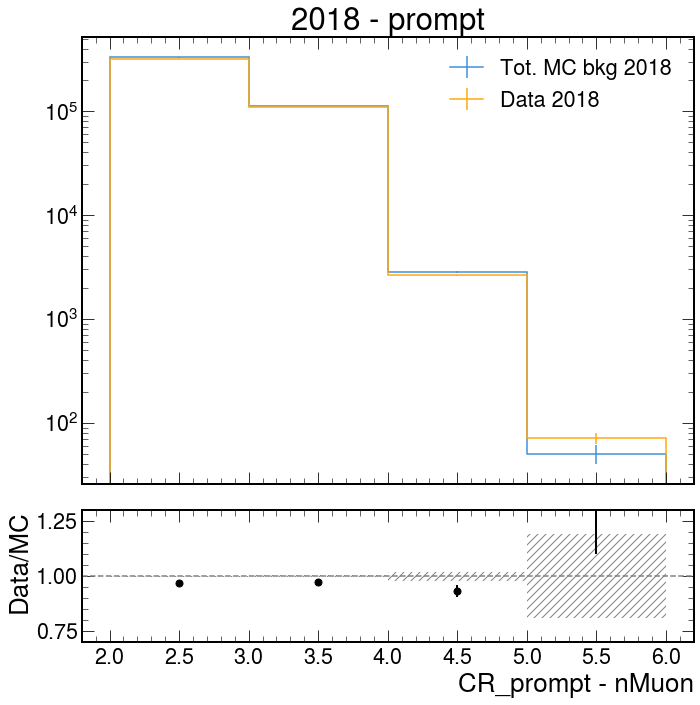

In [13]:
regions = ["prompt"]  # , "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]

for region in regions:
    for era in ["2018"]:
        hist_data = plots[f"Data_{era}"][f"CR_{region}_ip3d"][::sum, :]
        hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}_ip3d"][::sum, :]

        # Normalize
        # normalization = hist_data.sum().value / hist_bkg_total.sum().value
        # hist_bkg_total = hist_bkg_total * normalization

        fig = plt.figure(figsize=(10, 10))
        plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
        ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
        ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

        hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
        hist_data.plot(label=f"Data {era}", ax=ax1)

        x_hatch = np.vstack(
            (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
        ).reshape((-1,), order="F")

        ratio = np.divide(
            hist_data.values(),
            hist_bkg_total.values(),
            out=np.ones_like(hist_data.values()),
            where=hist_bkg_total.values() != 0,
        )
        ratio_err = np.where(
            hist_bkg_total.values() > 0,
            np.sqrt(
                (hist_bkg_total.values() ** -2) * (hist_data.variances())
                + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                * (hist_bkg_total.variances())
            ),
            0,
        )
        ax2.errorbar(
            hist_data.axes.centers[0],
            ratio,
            yerr=ratio_err,
            color="black",
            fmt="o",
            linestyle="none",
            markersize=7,
            lw=2,
        )

        # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
        mc_rel_unc = np.divide(
            np.sqrt(hist_bkg_total.variances()),
            hist_bkg_total.values(),
            out=np.zeros_like(hist_bkg_total.values()),
            where=hist_bkg_total.values() != 0,
        )
        y_hatch2 = np.vstack(
            (
                np.ones_like(hist_bkg_total.values()),
                np.ones_like(hist_bkg_total.values()),
            )
        ).reshape((-1,), order="F")
        y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
        ax2.fill_between(
            x=x_hatch,
            y1=y_hatch2 - y_hatch2_unc,
            y2=y_hatch2 + y_hatch2_unc,
            step="pre",
            facecolor="none",
            edgecolor=(0, 0, 0, 0.5),
            linewidth=0,
            hatch="///",
        )
        ax2.axhline(1, ls="--", color="gray")

        plt.sca(ax2)
        plt.xlabel(f"CR_{region} - nMuon")
        ax1.set_yscale("log")
        plt.ylim(0.7, 1.3)
        plt.ylabel("Data/MC")
        plt.setp(ax1.get_xticklabels(), visible=False)
        ax1.set_xlabel("", visible=False)
        ax1.set_title(f"{era} - {region}")
        ax1.legend()
        plt.show()

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

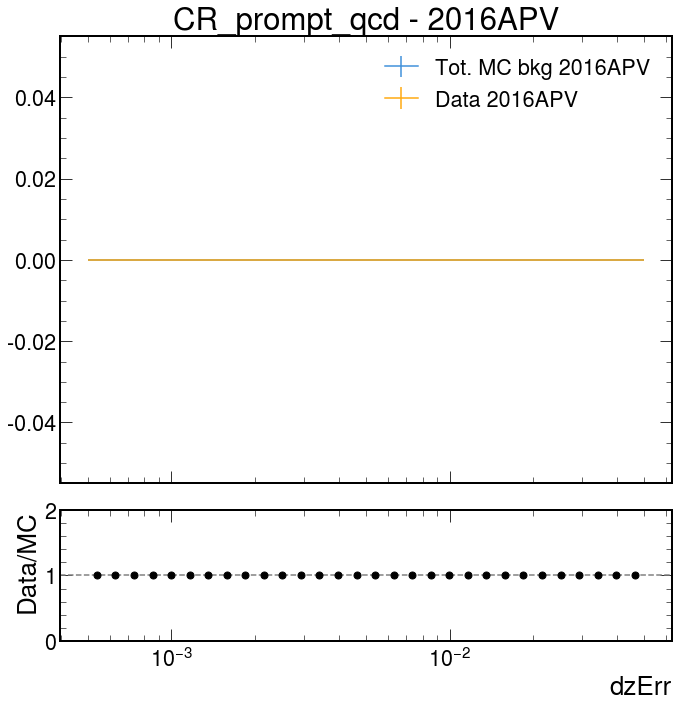

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


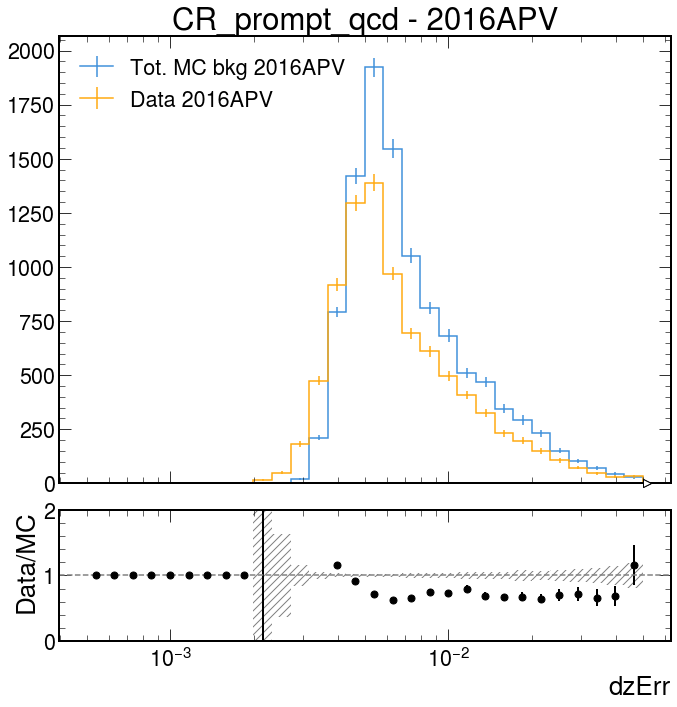

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


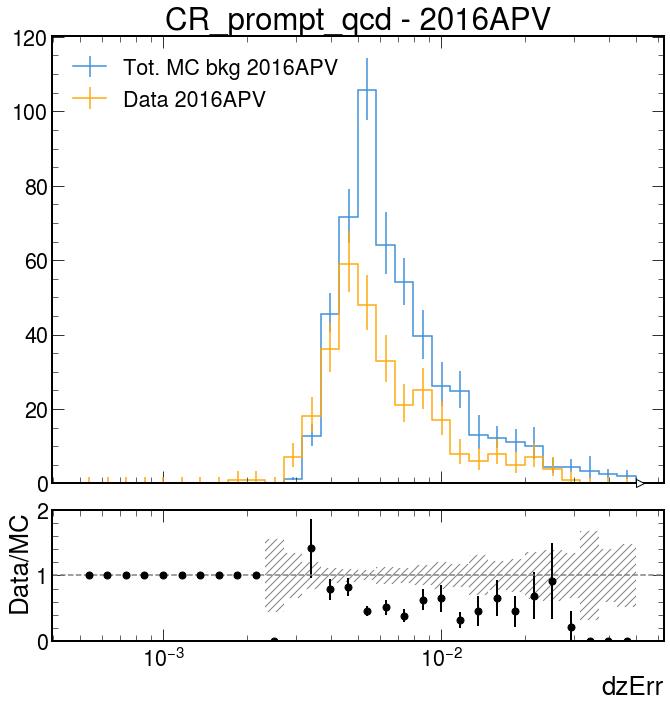

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


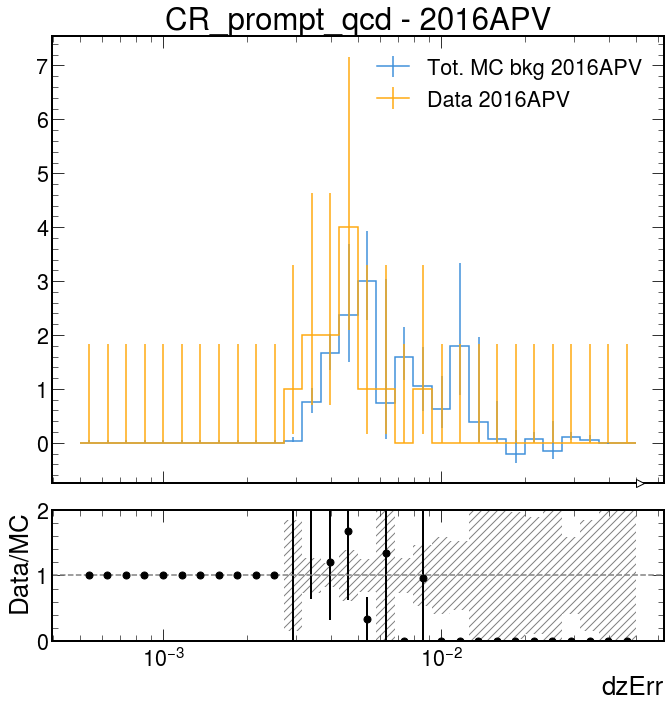

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

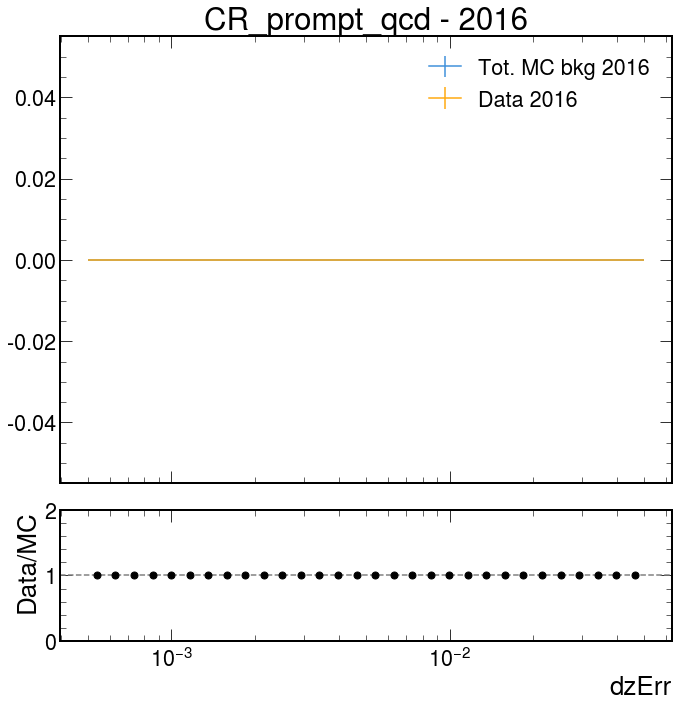

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


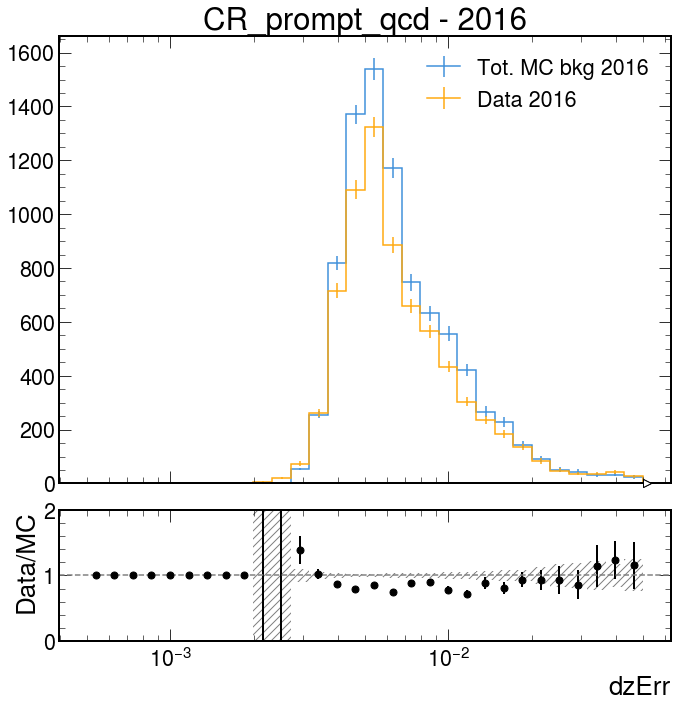

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


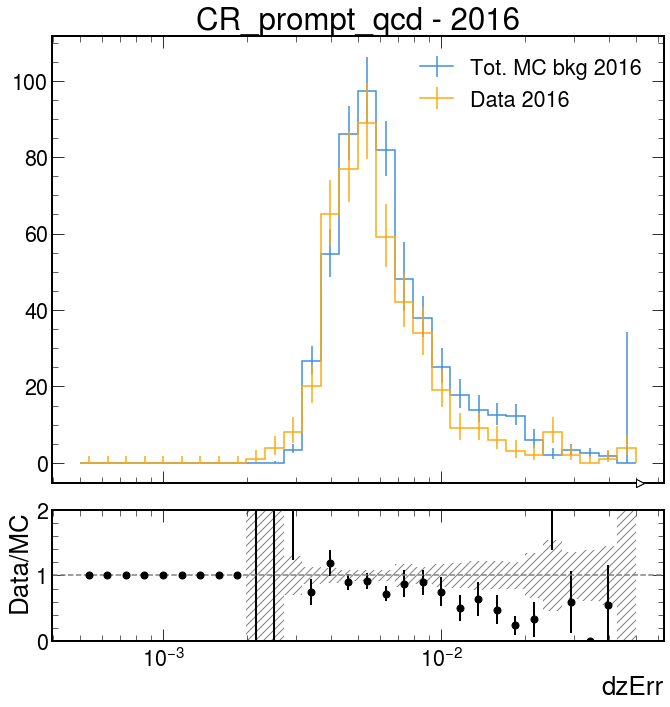

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


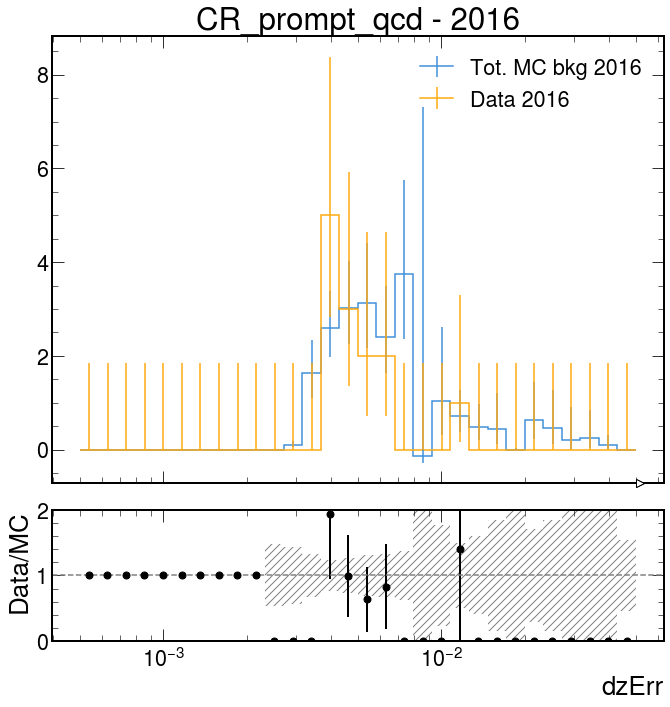

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

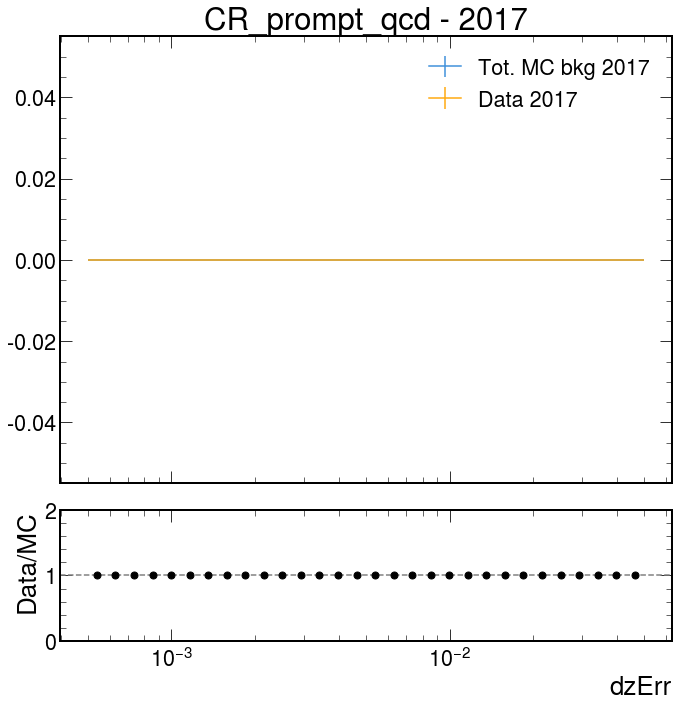

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


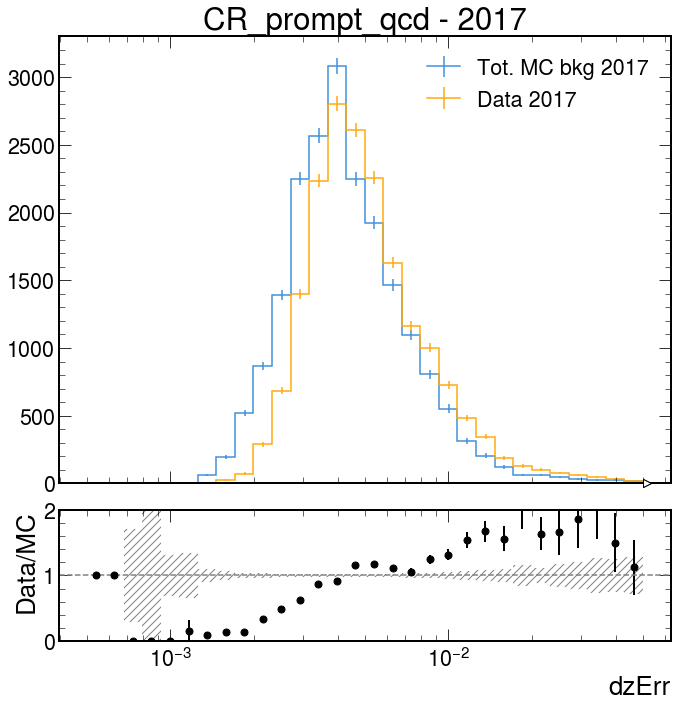

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


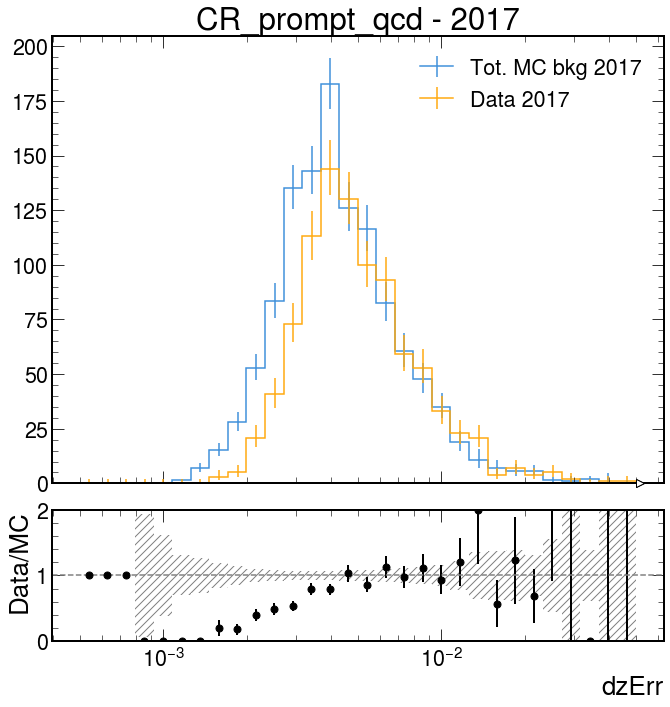

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


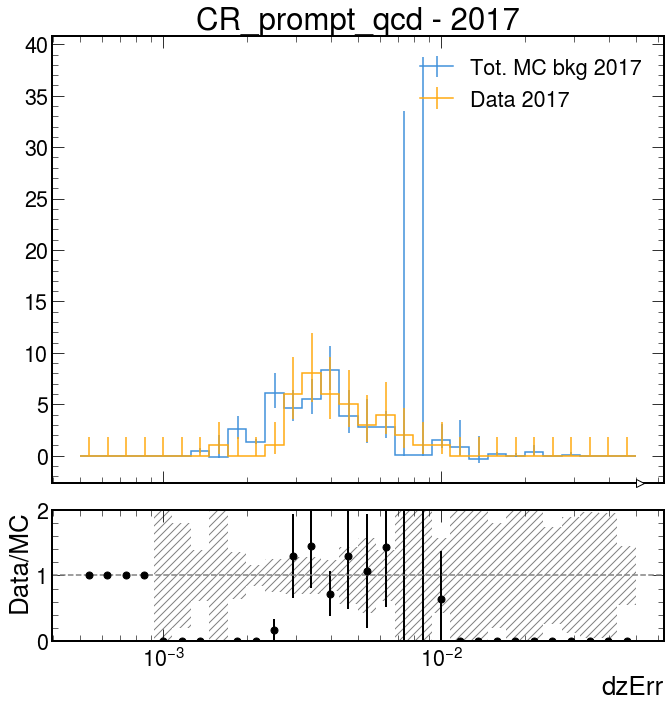

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

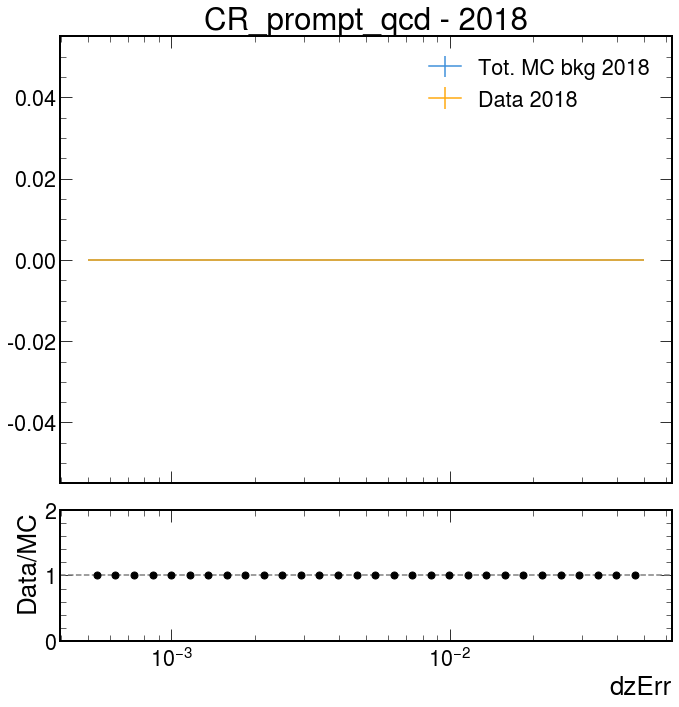

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


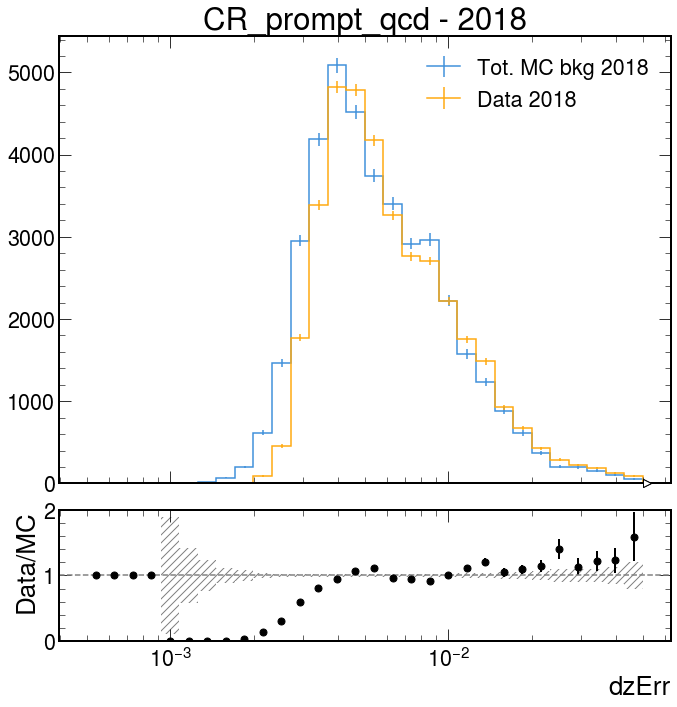

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


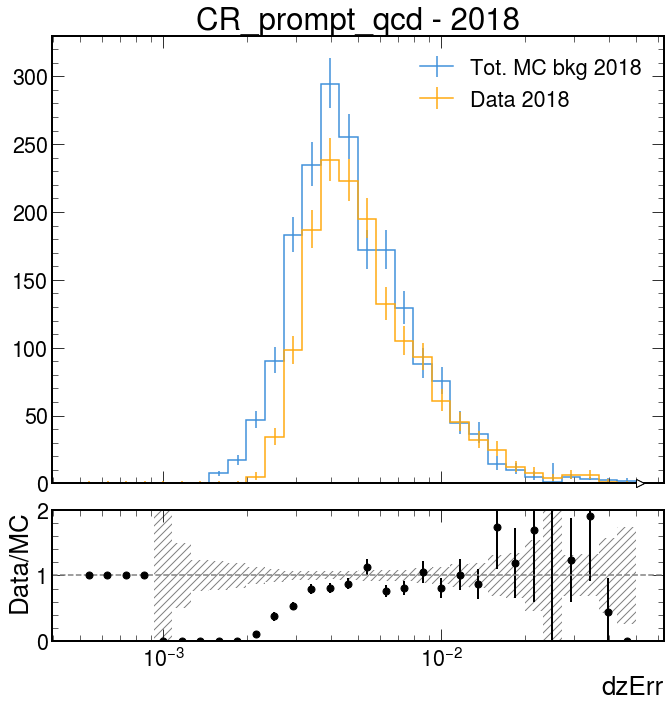

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


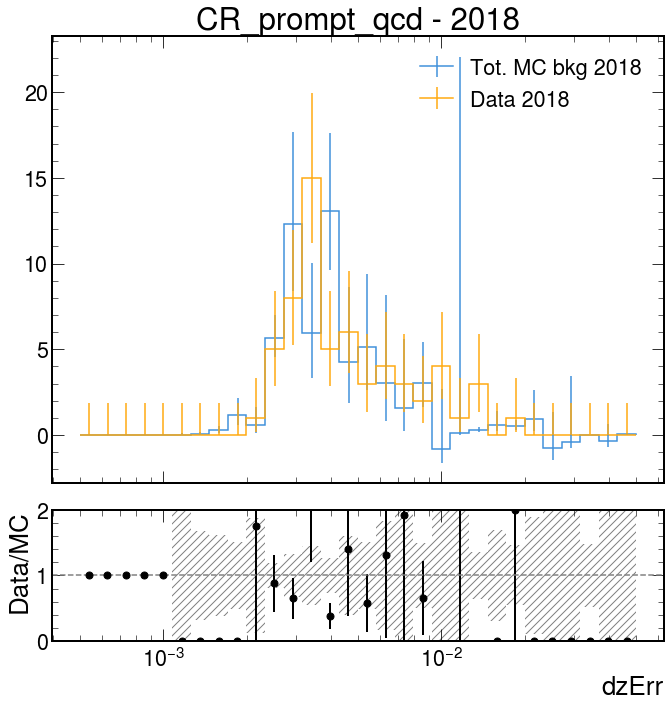

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

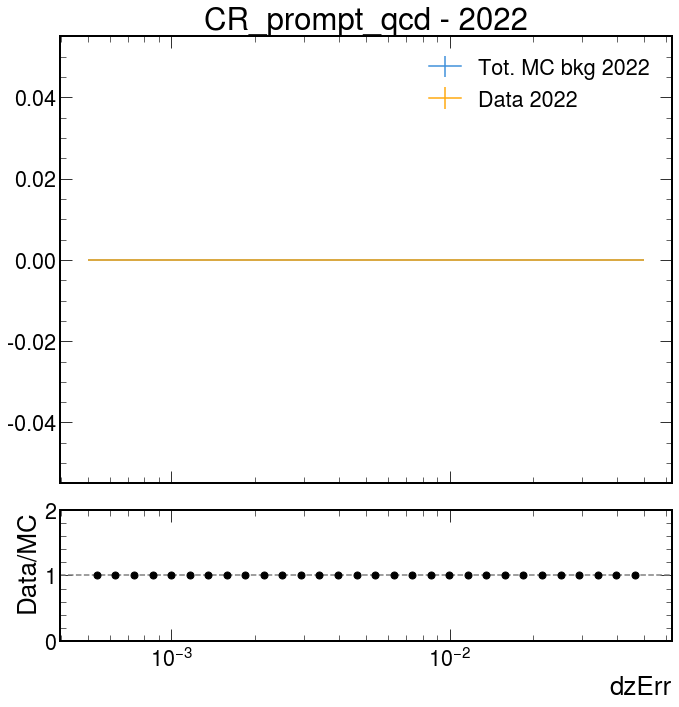

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


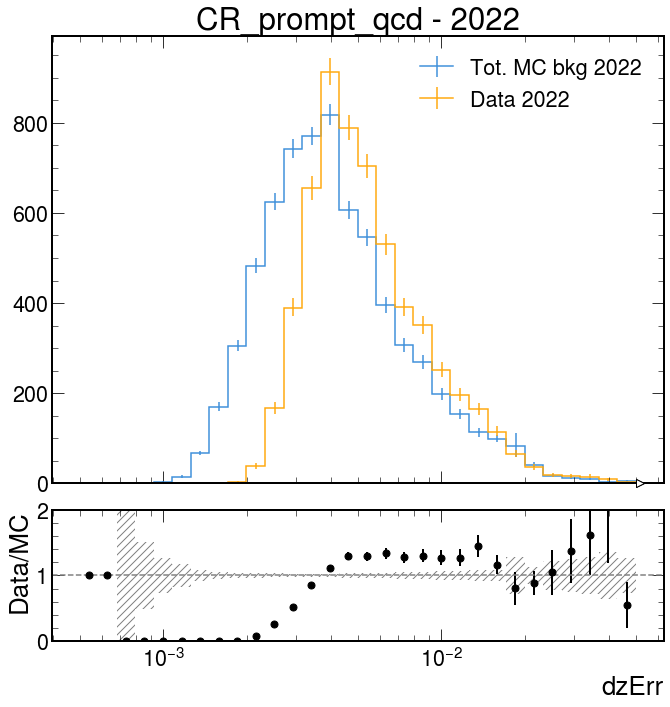

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


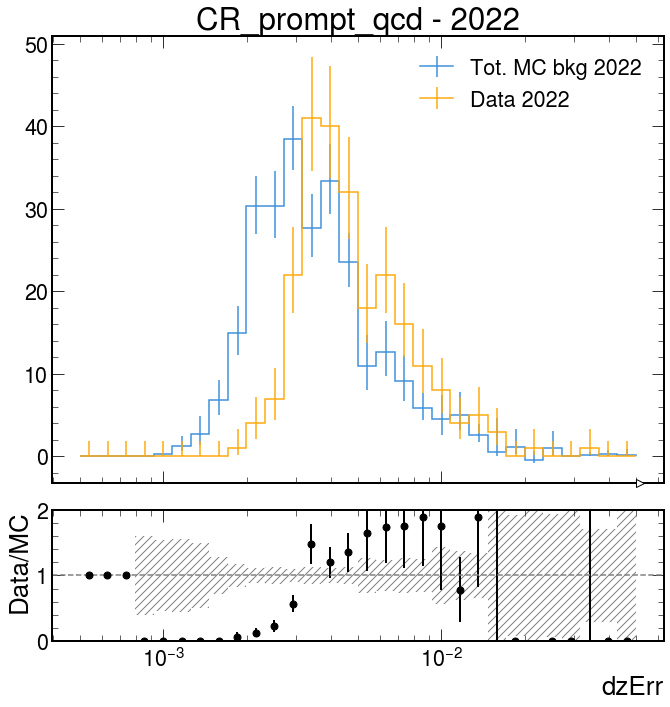

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


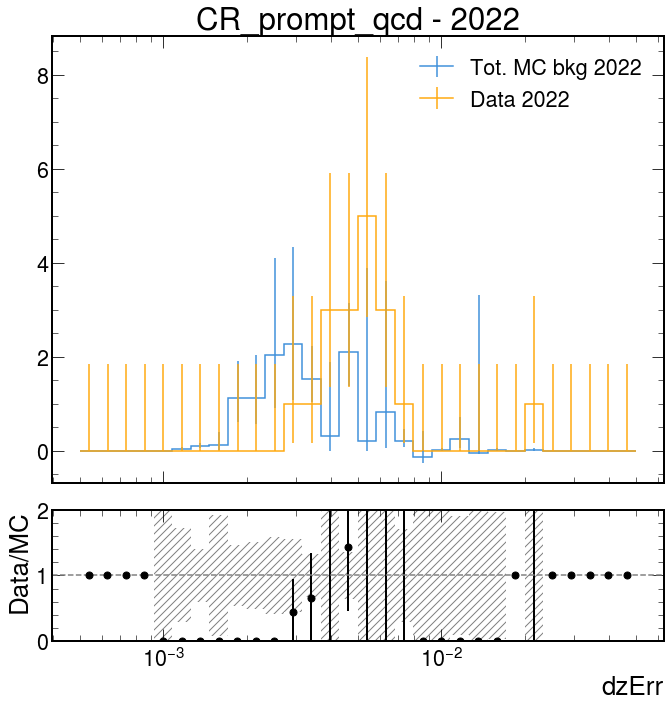

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

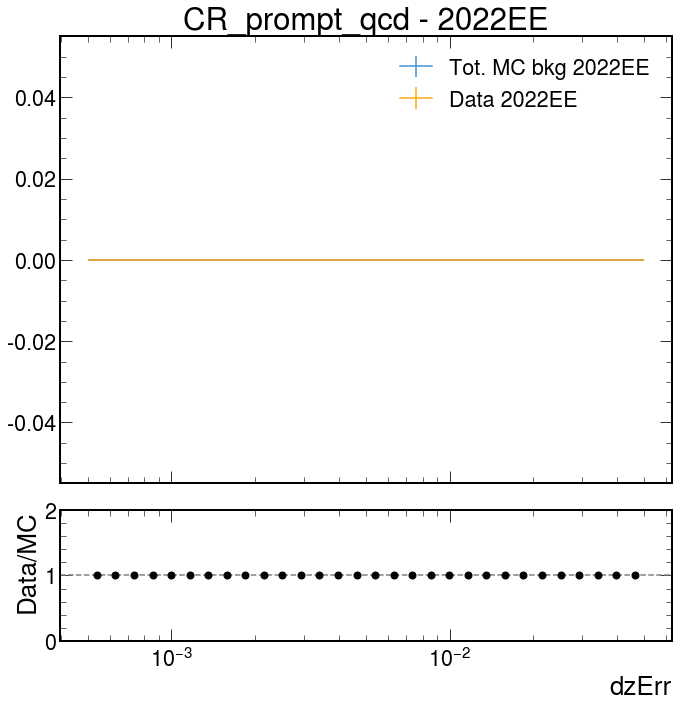

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


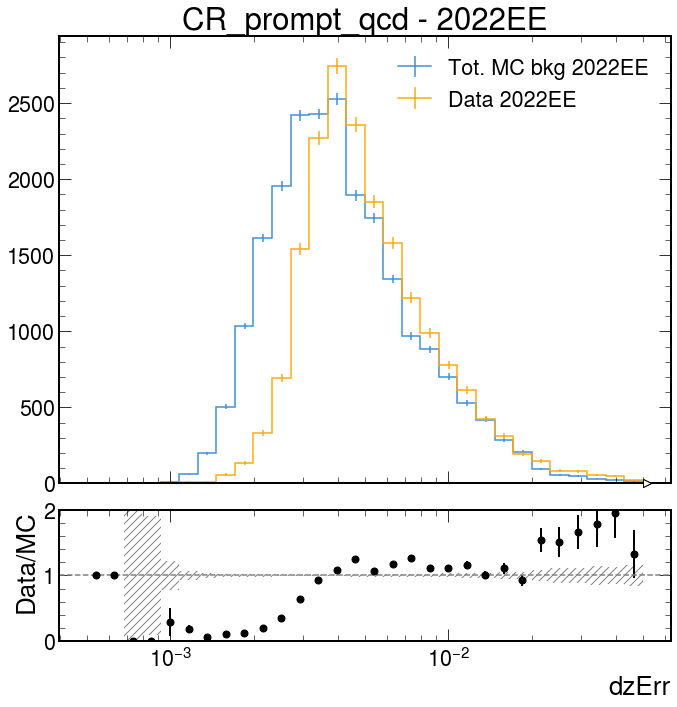

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


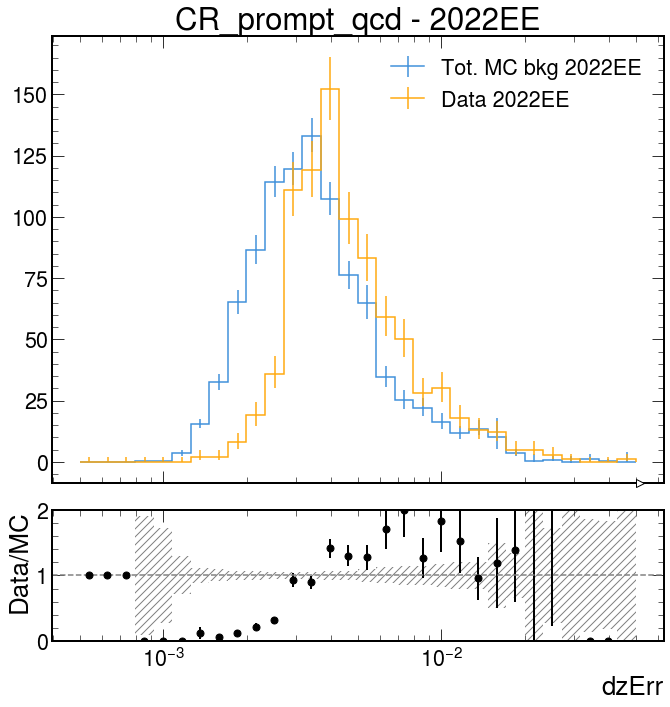

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


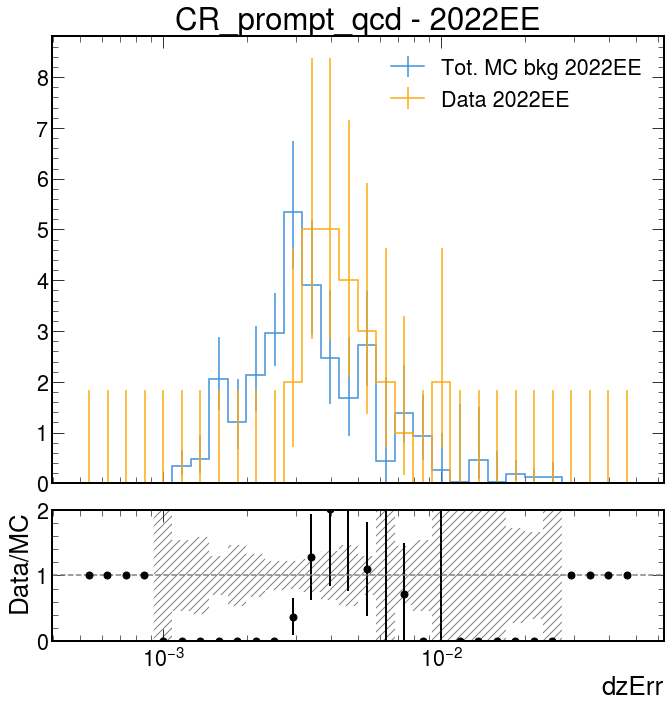

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

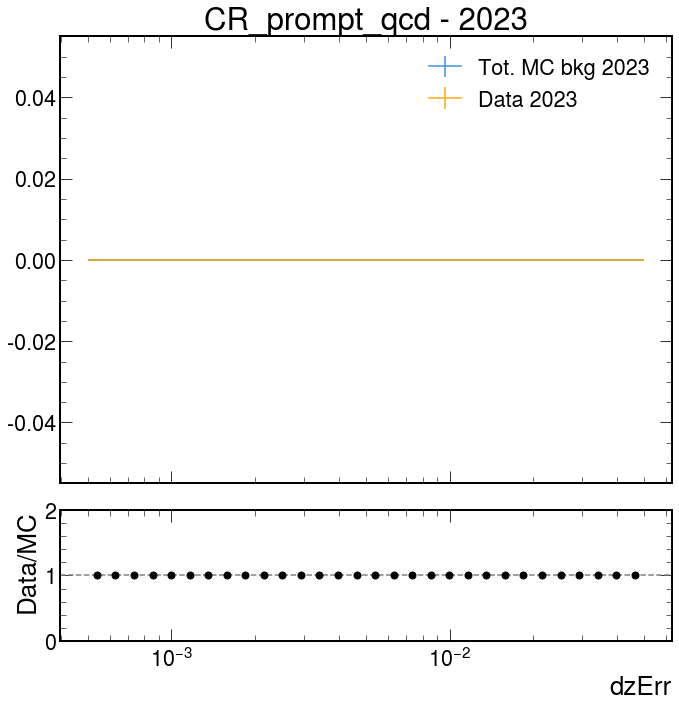

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


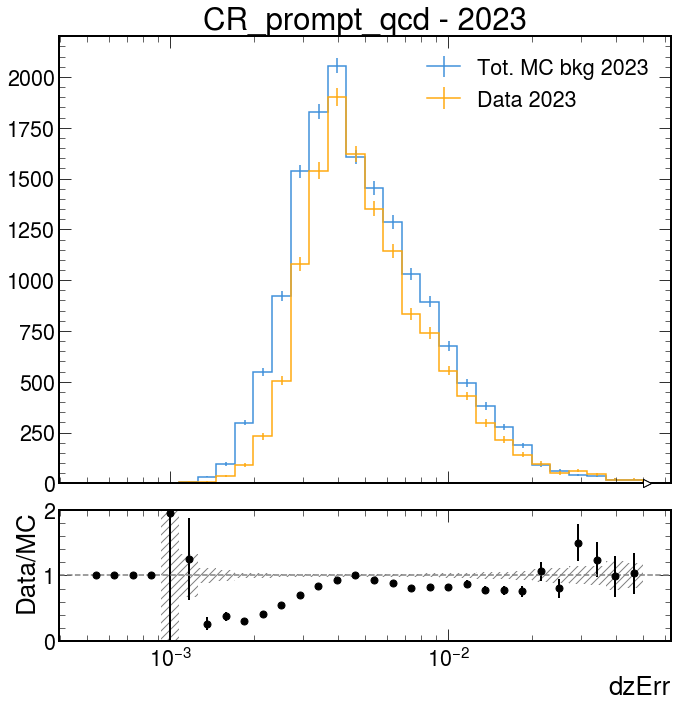

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


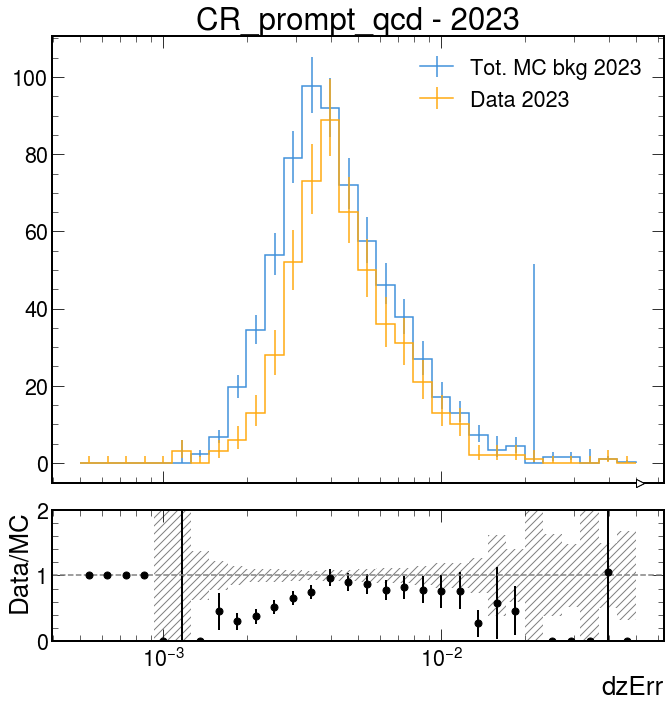

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


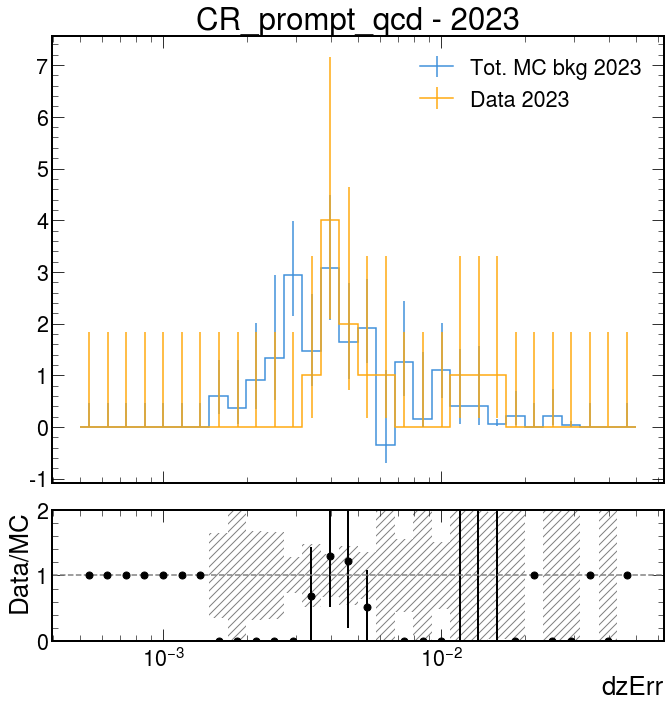

nMuon =  2.0

/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms_data/d3/chpapage/SUEPs/MuonTriggers/muon_branches/SUEPCoffea_dask/myenv/lib/python3.11/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/

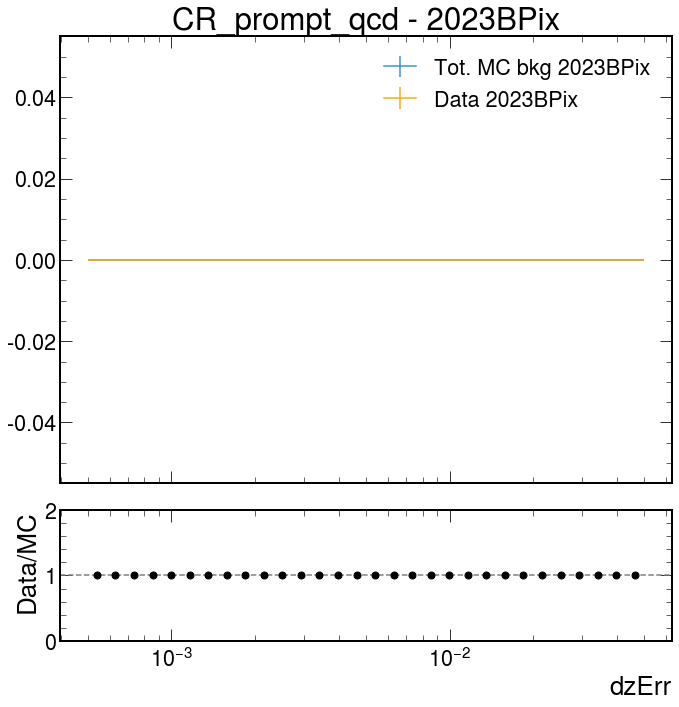

nMuon =  3.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


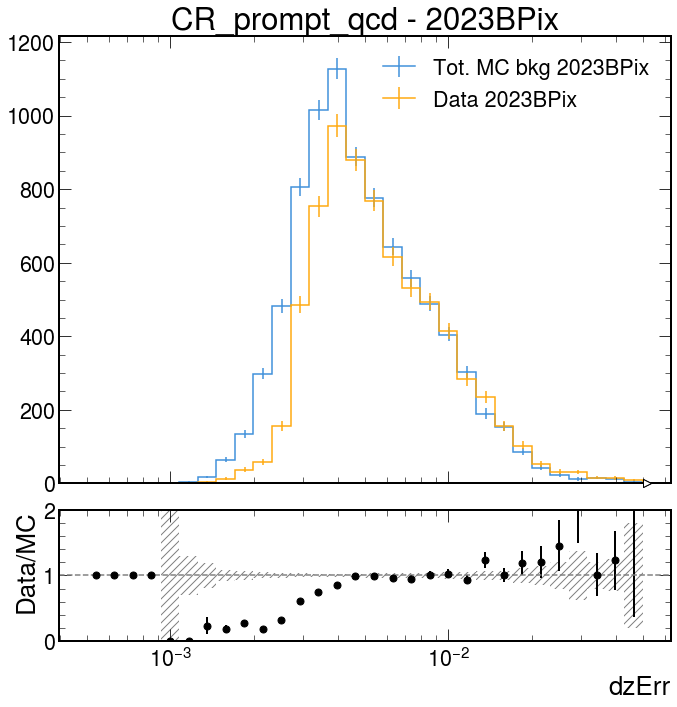

nMuon =  4.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


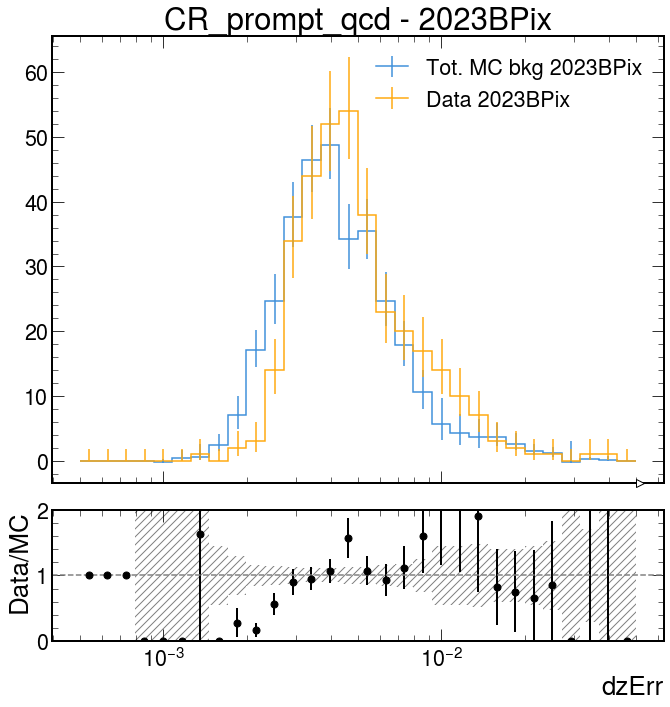

nMuon =  5.0

/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:34: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_3362541/2400525709.py:35: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


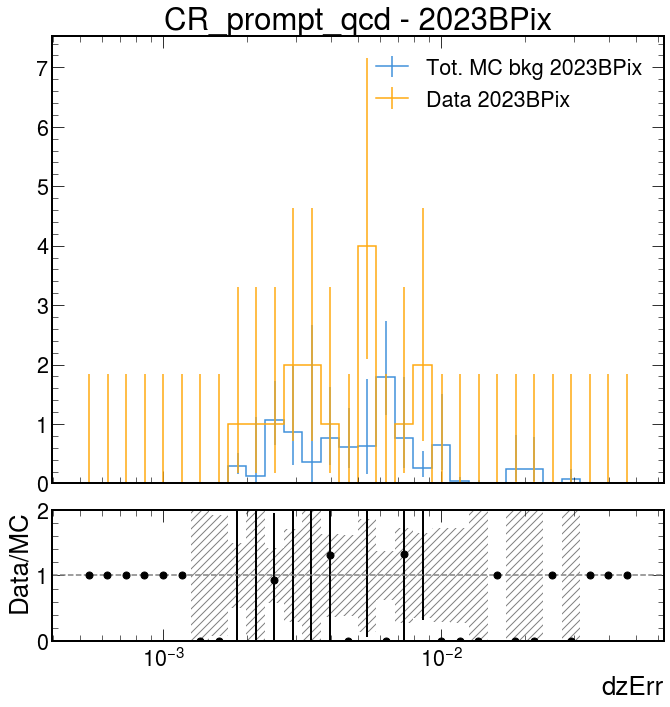

In [37]:
for era in ["2016APV", "2016", "2017", "2018", "2022", "2022EE", "2023", "2023BPix"]:
    for region in ["prompt_qcd"]:  # ["prompt_prompt", "prompt_qcd", "cb"]:
        for variable in [
            f"CR_{region}_dz_vs_dzErr"
        ]:  # [f"CR_{region}_dxy_vs_dxyErr", f"CR_{region}_dz_vs_dzErr"]:
            for nMuon in plots[f"Data_{year}"][variable].axes[2].edges[:-1]:
                print("nMuon = ", nMuon)
                hist_data = plots[f"Data_{era}"][variable][::sum, :, nMuon * 1j]
                hist_bkg_total = plots[f"total_bkg_{era}"][variable][
                    ::sum, :, nMuon * 1j
                ]

                # Normalize
                # normalization = hist_data.sum().value / hist_bkg_total.sum().value
                # hist_bkg_total = hist_bkg_total * normalization

                fig = plt.figure(figsize=(10, 10))
                plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
                ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
                ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

                hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
                hist_data.plot(label=f"Data {era}", ax=ax1)

                x_hatch = np.vstack(
                    (
                        hist_bkg_total.axes[0].edges[:-1],
                        hist_bkg_total.axes[0].edges[1:],
                    )
                ).reshape((-1,), order="F")

                ratio = np.divide(
                    hist_data.values(),
                    hist_bkg_total.values(),
                    out=np.ones_like(hist_data.values()),
                    where=hist_bkg_total.values() != 0,
                )
                ratio_err = np.where(
                    hist_bkg_total.values() > 0,
                    np.sqrt(
                        (hist_bkg_total.values() ** -2) * (hist_data.variances())
                        + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                        * (hist_bkg_total.variances())
                    ),
                    0,
                )
                ax2.errorbar(
                    hist_data.axes.centers[0],
                    ratio,
                    yerr=ratio_err,
                    color="black",
                    fmt="o",
                    linestyle="none",
                    markersize=7,
                    lw=2,
                )

                # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
                mc_rel_unc = np.divide(
                    np.sqrt(hist_bkg_total.variances()),
                    hist_bkg_total.values(),
                    out=np.zeros_like(hist_bkg_total.values()),
                    where=hist_bkg_total.values() != 0,
                )
                y_hatch2 = np.vstack(
                    (
                        np.ones_like(hist_bkg_total.values()),
                        np.ones_like(hist_bkg_total.values()),
                    )
                ).reshape((-1,), order="F")
                y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape(
                    (-1,), order="F"
                )
                ax2.fill_between(
                    x=x_hatch,
                    y1=y_hatch2 - y_hatch2_unc,
                    y2=y_hatch2 + y_hatch2_unc,
                    step="pre",
                    facecolor="none",
                    edgecolor=(0, 0, 0, 0.5),
                    linewidth=0,
                    hatch="///",
                )
                ax2.axhline(1, ls="--", color="gray")

                # ax1.set_yscale("log")
                plt.xscale("log")
                plt.sca(ax2)
                plt.xlabel(variable.split("_")[-1])
                plt.ylim(0.0, 2.0)
                plt.ylabel("Data/MC")
                plt.setp(ax1.get_xticklabels(), visible=False)
                ax1.set_xlabel("", visible=False)
                ax1.set_title(f"{'_'.join(variable.split('_')[:-3])} - {era}")
                ax1.legend()
                plt.show()

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


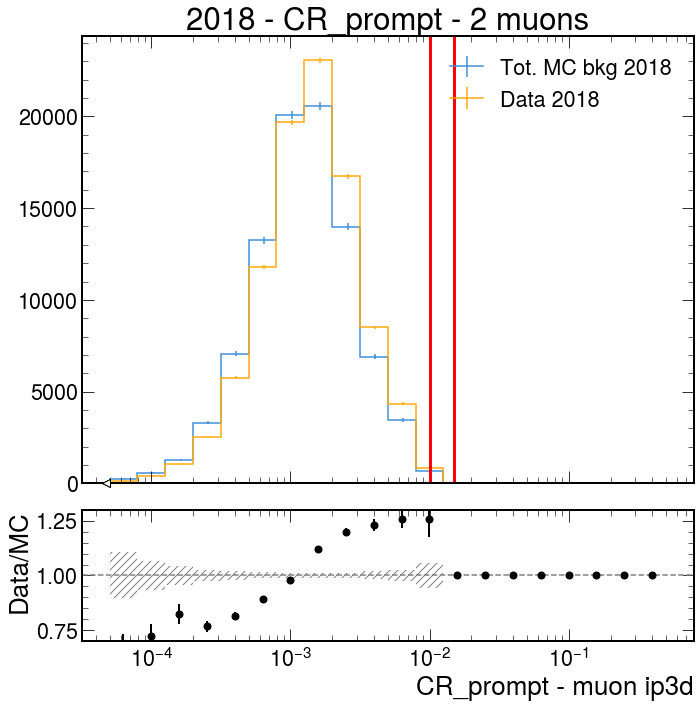

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


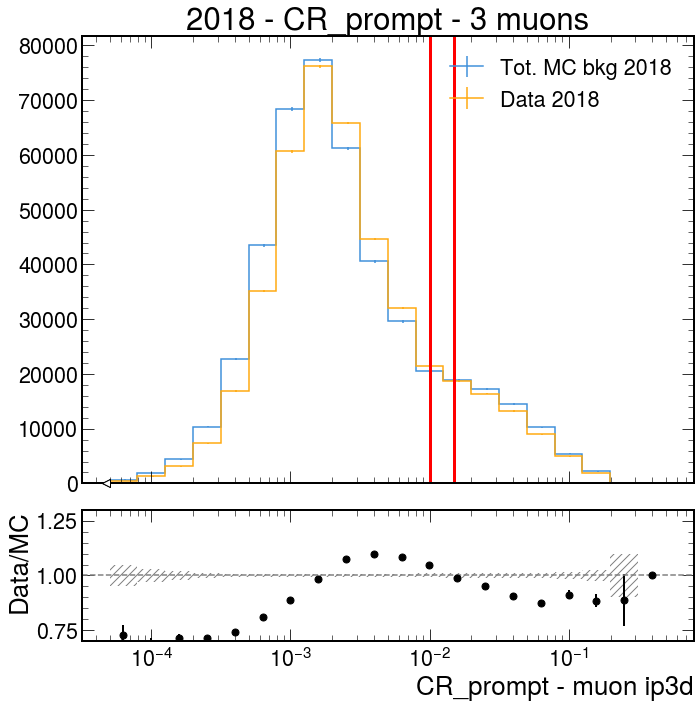

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


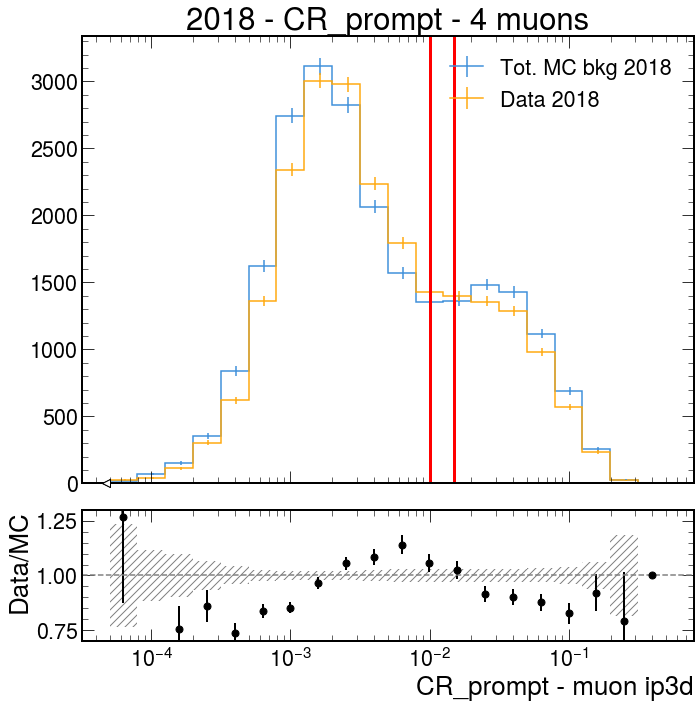

/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: divide by zero encountered in power
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:37: RuntimeWarning: invalid value encountered in multiply
  (hist_bkg_total.values() ** -2) * (hist_data.variances())
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: divide by zero encountered in power
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
/tmp/ipykernel_839174/156690244.py:38: RuntimeWarning: invalid value encountered in multiply
  + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)


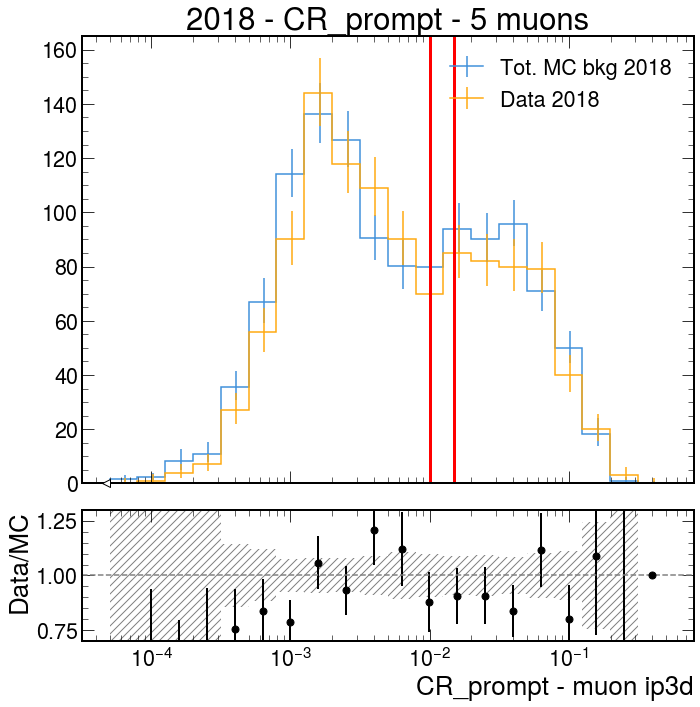

In [19]:
regions = ["prompt"]  # , "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]
variables = ["pt", "eta", "dxy", "dz", "ip3d", "iso"]

for region in regions:
    for era in ["2018"]:
        for nMuon in range(2, 6):
            variable = "ip3d"
            hist_data = plots[f"Data_{era}"][f"CR_{region}_{variable}"][:, nMuon * 1j]
            hist_bkg_total = plots[f"total_bkg_{era}"][f"CR_{region}_{variable}"][
                :, nMuon * 1j
            ]

            # Normalize
            # normalization = hist_data.sum().value / hist_bkg_total.sum().value
            # hist_bkg_total = hist_bkg_total * normalization

            fig = plt.figure(figsize=(10, 10))
            plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
            ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
            ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

            hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
            hist_data.plot(label=f"Data {era}", ax=ax1)

            x_hatch = np.vstack(
                (hist_bkg_total.axes[0].edges[:-1], hist_bkg_total.axes[0].edges[1:])
            ).reshape((-1,), order="F")

            ratio = np.divide(
                hist_data.values(),
                hist_bkg_total.values(),
                out=np.ones_like(hist_data.values()),
                where=hist_bkg_total.values() != 0,
            )
            ratio_err = np.where(
                hist_bkg_total.values() > 0,
                np.sqrt(
                    (hist_bkg_total.values() ** -2) * (hist_data.variances())
                    + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                    * (hist_bkg_total.variances())
                ),
                0,
            )
            ax2.errorbar(
                hist_data.axes.centers[0],
                ratio,
                yerr=ratio_err,
                color="black",
                fmt="o",
                linestyle="none",
                markersize=7,
                lw=2,
            )

            # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
            mc_rel_unc = np.divide(
                np.sqrt(hist_bkg_total.variances()),
                hist_bkg_total.values(),
                out=np.zeros_like(hist_bkg_total.values()),
                where=hist_bkg_total.values() != 0,
            )
            y_hatch2 = np.vstack(
                (
                    np.ones_like(hist_bkg_total.values()),
                    np.ones_like(hist_bkg_total.values()),
                )
            ).reshape((-1,), order="F")
            y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape((-1,), order="F")
            ax2.fill_between(
                x=x_hatch,
                y1=y_hatch2 - y_hatch2_unc,
                y2=y_hatch2 + y_hatch2_unc,
                step="pre",
                facecolor="none",
                edgecolor=(0, 0, 0, 0.5),
                linewidth=0,
                hatch="///",
            )
            ax2.axhline(1, ls="--", color="gray")

            if variable == "pt":
                ax1.axvline(x=25, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "iso":
                ax1.axvline(x=0.1, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "dxy":
                ax1.axvline(x=0.008, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "dz":
                ax1.axvline(x=0.01, color="red", ymin=0, ymax=1e6, lw=3)
            if variable == "ip3d":
                ax1.axvline(x=0.01, color="red", ymin=0, ymax=1e6, lw=3)
                ax1.axvline(x=0.015, color="red", ymin=0, ymax=1e6, lw=3)

            if variable in ["pt", "dxy", "dz", "ip3d", "iso"]:
                plt.xscale("log")
            plt.sca(ax2)
            plt.xlabel(f"CR_{region} - muon {variable}")
            plt.ylim(0.7, 1.3)
            plt.ylabel("Data/MC")
            plt.setp(ax1.get_xticklabels(), visible=False)
            ax1.set_xlabel("", visible=False)
            ax1.set_title(f"{era} - CR_{region} - {nMuon} muons")
            ax1.legend()
            plt.show()

In [38]:
regions = ["prompt", "cb"]
eras = [
    "2016APV",
    "2016",
    "2017",
    "2018",
    "Run2",
    "2022",
    "2022EE",
    "2023",
    "2023BPix",
    "Run3",
]
variables = ["pt", "eta", "dxy", "dz", "ip3d", "iso"]

with PdfPages("data_vs_mc_nMuon2.pdf") as pdf:
    with Progress() as progress:
        task = progress.add_task(
            "Plotting", total=len(regions) * len(eras) * len(variables)
        )
        for region in regions:
            for era in eras:
                for variable in variables:
                    hist_data = plots[f"Data_{era}"][f"CR_{region}_{variable}"][:, 2j]
                    hist_bkg_total = plots[f"total_bkg_{era}"][
                        f"CR_{region}_{variable}"
                    ][:, 2j]

                    normalization = hist_data.sum().value / hist_bkg_total.sum().value
                    hist_bkg_total = hist_bkg_total * normalization

                    fig = plt.figure(figsize=(10, 10))
                    plt.subplots_adjust(bottom=0.08, top=0.92, left=0.1, right=0.95)
                    ax1 = plt.subplot2grid((4, 1), (0, 0), rowspan=3)
                    ax2 = plt.subplot2grid((4, 1), (3, 0), sharex=ax1)

                    hist_bkg_total.plot(label=f"Tot. MC bkg {era}", ax=ax1)
                    hist_data.plot(label=f"Data {era}", ax=ax1)

                    x_hatch = np.vstack(
                        (
                            hist_bkg_total.axes[0].edges[:-1],
                            hist_bkg_total.axes[0].edges[1:],
                        )
                    ).reshape((-1,), order="F")

                    ratio = np.divide(
                        hist_data.values(),
                        hist_bkg_total.values(),
                        out=np.ones_like(hist_data.values()),
                        where=hist_bkg_total.values() != 0,
                    )
                    ratio_err = np.where(
                        hist_bkg_total.values() > 0,
                        np.sqrt(
                            (hist_bkg_total.values() ** -2) * (hist_data.variances())
                            + (hist_data.values() ** 2 * hist_bkg_total.values() ** -4)
                            * (hist_bkg_total.variances())
                        ),
                        0,
                    )
                    ax2.errorbar(
                        hist_data.axes.centers[0],
                        ratio,
                        yerr=ratio_err,
                        color="black",
                        fmt="o",
                        linestyle="none",
                        markersize=7,
                        lw=2,
                    )

                    # Draw a filled hatch area with the relative uncertainty of the MC in the ratio plot.
                    mc_rel_unc = np.divide(
                        np.sqrt(hist_bkg_total.variances()),
                        hist_bkg_total.values(),
                        out=np.zeros_like(hist_bkg_total.values()),
                        where=hist_bkg_total.values() != 0,
                    )
                    y_hatch2 = np.vstack(
                        (
                            np.ones_like(hist_bkg_total.values()),
                            np.ones_like(hist_bkg_total.values()),
                        )
                    ).reshape((-1,), order="F")
                    y_hatch2_unc = np.vstack((mc_rel_unc, mc_rel_unc)).reshape(
                        (-1,), order="F"
                    )
                    ax2.fill_between(
                        x=x_hatch,
                        y1=y_hatch2 - y_hatch2_unc,
                        y2=y_hatch2 + y_hatch2_unc,
                        step="pre",
                        facecolor="none",
                        edgecolor=(0, 0, 0, 0.5),
                        linewidth=0,
                        hatch="///",
                    )
                    ax2.axhline(1, ls="--", color="gray")

                    if variable in ["pt", "ip3d", "iso"]:
                        plt.xscale("log")
                    plt.sca(ax2)
                    plt.xlabel(f"CR_{region} - muon {variable}")
                    plt.ylim(0.75, 1.25)
                    plt.ylabel("Data/MC")
                    plt.setp(ax1.get_xticklabels(), visible=False)
                    ax1.set_xlabel("", visible=False)
                    ax1.set_title(f"{era} - {region}")
                    ax1.legend()
                    pdf.savefig(fig)  # Saves the current figure into the PDF
                    plt.close(fig)  # Close the figure after saving to free memory
                    progress.update(task, advance=1)

Plotting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01
Plotting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01